Loading Overlay...


Processing Input Image...


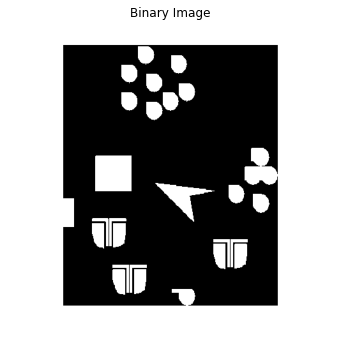

      Preprocessing complete
Allocating Buffers...
Starting Parallel Slices...
Slices Done in 0.0125s
Stitching complete. Ready for Verification.


In [1]:
from pynq import Overlay, allocate, MMIO
import numpy as np
import cv2
import time
import PIL.Image
from IPython.display import display
import matplotlib.pyplot as plt

# ==========================================
# 1. Helper: Safe Driver
# ==========================================

def get_safe_driver(ip_name):
    phys_addr = ol.ip_dict[ip_name]['phys_addr']
    return MMIO(phys_addr, 0x10000)

# ==========================================
# 2. Load Hardware
# ==========================================
print("Loading Overlay...")
ol = Overlay("/home/xilinx/pynq/overlays/proiect/top.bit")

dma_slice_0 = ol.axi_dma_0
dma_slice_1 = ol.axi_dma_1
dma_slice_2 = ol.axi_dma_2
dma_slice_3 = ol.axi_dma_3
dma_relabel = ol.axi_dma_5

slice_0_ctrl = get_safe_driver('ccl_slice_core_0')
slice_1_ctrl = get_safe_driver('ccl_slice_core_1')
slice_2_ctrl = get_safe_driver('ccl_slice_core_2')
slice_3_ctrl = get_safe_driver('ccl_slice_core_3')
relabel_ctrl = get_safe_driver('ccl_relabel_core_0')

# ==========================================
# 3. Process Input Image (CORRECTED & FIXED BIT ORDER)
# ==========================================
print("Processing Input Image...")
input_path = "images/utcn_logos.jpg" 

image = cv2.imread(input_path)
if image is None:
    raise FileNotFoundError(f"Could not read image from {input_path}")

resized = cv2.resize(image, (512, 512), interpolation=cv2.INTER_AREA)

gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

plt.figure(figsize=(6, 6))
plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis('off')
plt.show()

flattened = (binary // 255).astype(np.uint32).flatten()
packed_image = np.zeros(len(flattened) // 32, dtype=np.uint32)
for i in range(32):
    packed_image |= (flattened[i::32] << (31 - i))

print("      Preprocessing complete")

# ==========================================
# 4. Memory Allocation
# ==========================================
SLICE_SIZE_PACKED = 2048      
SLICE_PIXELS = 512 * 128      
FULL_FRAME_LABELS = 512 * 512 

print("Allocating Buffers...")
in_buf_0 = allocate(shape=(SLICE_SIZE_PACKED,), dtype=np.uint32)
in_buf_1 = allocate(shape=(SLICE_SIZE_PACKED,), dtype=np.uint32)
in_buf_2 = allocate(shape=(SLICE_SIZE_PACKED,), dtype=np.uint32)
in_buf_3 = allocate(shape=(SLICE_SIZE_PACKED,), dtype=np.uint32)

mid_buf_0 = allocate(shape=(SLICE_PIXELS,), dtype=np.uint32)
mid_buf_1 = allocate(shape=(SLICE_PIXELS,), dtype=np.uint32)
mid_buf_2 = allocate(shape=(SLICE_PIXELS,), dtype=np.uint32)
mid_buf_3 = allocate(shape=(SLICE_PIXELS,), dtype=np.uint32)

combined_buf = allocate(shape=(FULL_FRAME_LABELS,), dtype=np.uint32)
final_buf = allocate(shape=(FULL_FRAME_LABELS,), dtype=np.uint32)

in_buf_0[:] = packed_image[0:2048]
in_buf_1[:] = packed_image[2048:4096]
in_buf_2[:] = packed_image[4096:6144]
in_buf_3[:] = packed_image[6144:8192]

# ==========================================
# 5. Execute Parallel Slices
# ==========================================
print("Starting Parallel Slices...")
start_time = time.time()

for ctrl in [slice_0_ctrl, slice_1_ctrl, slice_2_ctrl, slice_3_ctrl, relabel_ctrl]:
    ctrl.write(0x00, 0)

dma_slice_0.recvchannel.transfer(mid_buf_0)
dma_slice_1.recvchannel.transfer(mid_buf_1)
dma_slice_2.recvchannel.transfer(mid_buf_2)
dma_slice_3.recvchannel.transfer(mid_buf_3)

dma_slice_0.sendchannel.transfer(in_buf_0)
dma_slice_1.sendchannel.transfer(in_buf_1)
dma_slice_2.sendchannel.transfer(in_buf_2)
dma_slice_3.sendchannel.transfer(in_buf_3)

slice_0_ctrl.write(0x00, 1)
slice_1_ctrl.write(0x00, 1)
slice_2_ctrl.write(0x00, 1)
slice_3_ctrl.write(0x00, 1)

dma_slice_0.recvchannel.wait()
dma_slice_1.recvchannel.wait()
dma_slice_2.recvchannel.wait()
dma_slice_3.recvchannel.wait()

print(f"Slices Done in {time.time() - start_time:.4f}s")

# ==========================================
# 6. Stitching
# ==========================================
combined_buf[0:SLICE_PIXELS]                = mid_buf_0
combined_buf[SLICE_PIXELS:2*SLICE_PIXELS]   = mid_buf_1
combined_buf[2*SLICE_PIXELS:3*SLICE_PIXELS] = mid_buf_2
combined_buf[3*SLICE_PIXELS:4*SLICE_PIXELS] = mid_buf_3

print("Stitching complete. Ready for Verification.")

--- Verify Slice Core Outputs ---
Slice      | Status     | Min Val  | Max Val  | Non-Zero Pixels
---------------------------------------------------------------------------
Slice 0    | OK         | 0        | 9        | 38485 (58.7% coverage)
Slice 1    | OK         | 0        | 16397    | 28194 (43.0% coverage)
Slice 2    | OK         | 0        | 32786    | 30704 (46.9% coverage)
Slice 3    | OK         | 0        | 49162    | 47755 (72.9% coverage)
---------------------------------------------------------------------------

SUCCESS Data detected. Visualizing slices...


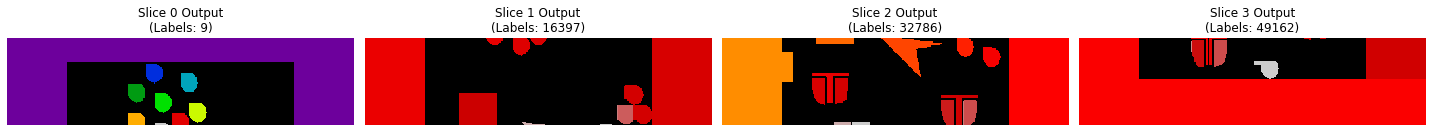

Combined Buffer (Stitching)...
 -> Buffer stitching logic correct


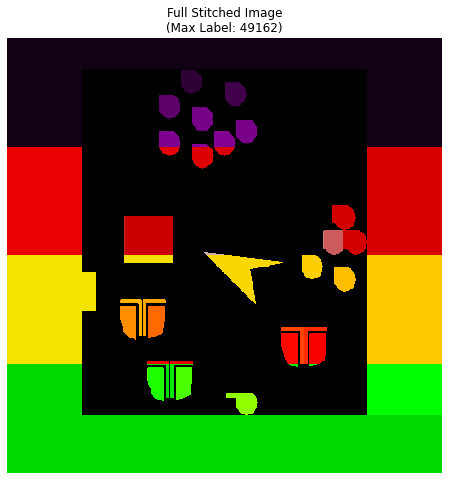

In [2]:
import numpy as np
import matplotlib.pyplot as plt

print("--- Verify Slice Core Outputs ---")

slice_buffers = [mid_buf_0, mid_buf_1, mid_buf_2, mid_buf_3]
total_pixels = 0
all_empty = True

print(f"{'Slice':<10} | {'Status':<10} | {'Min Val':<8} | {'Max Val':<8} | {'Non-Zero Pixels'}")
print("-" * 75)

for i, buf in enumerate(slice_buffers):
    data = np.array(buf) 
    
    # stats
    min_val = np.min(data)
    max_val = np.max(data)
    non_zeros = np.count_nonzero(data)
    
    status = "EMPTY" if non_zeros == 0 else "OK"
    if non_zeros > 0: all_empty = False
    
    print(f"Slice {i:<4} | {status:<10} | {min_val:<8} | {max_val:<8} | {non_zeros} ({non_zeros/data.size:.1%} coverage)")
    
    if i > 0 and max_val == 0:
        print(f"    WARNING: Slice {i} output is all zeros.")

print("-" * 75)

# Visual Verification
if all_empty:
    print("\n FAIL All slice outputs are empty (0).")
else:
    print("\nSUCCESS Data detected. Visualizing slices...")
    
    # Create a subplot for each slice
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    for i, ax in enumerate(axes):
        slice_img = np.array(slice_buffers[i]).reshape((128, 512))
        
        # % ensures distinct objects are visible even if labels are very high 
        ax.imshow(slice_img % 100, cmap='nipy_spectral', interpolation='nearest') 
        
        ax.set_title(f"Slice {i} Output\n(Labels: {np.max(slice_img)})")
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

    print("Combined Buffer (Stitching)...")
    combined_img = np.array(combined_buf).reshape((512, 512))
    
    if np.array_equal(combined_img[0:128, :], slice_buffers[0].reshape(128,512)):
        print(" -> Buffer stitching logic correct")
        
        plt.figure(figsize=(8,8))
        plt.imshow(combined_img % 100, cmap='nipy_spectral', interpolation='nearest')
        plt.title(f"Full Stitched Image\n(Max Label: {np.max(combined_img)})")
        plt.axis('off')
        plt.show()
    else:
        print(" ->  Combined buffer does not match slice 0 data")

--- Step 7: Software Relabeling ---
    Loaded FPGA output. Max Label: 49162
    Scanning seams with Neighbor-Search...
    Found 2290 equivalences.
    Merging completed. Remapped to 49145 unique IDs.

--- Final Result: 32 Objects Detected ---
    Saved labeled image to: images/fpga/fpga_output_labeled.jpg
    Total Processing Time: 0.3106 seconds


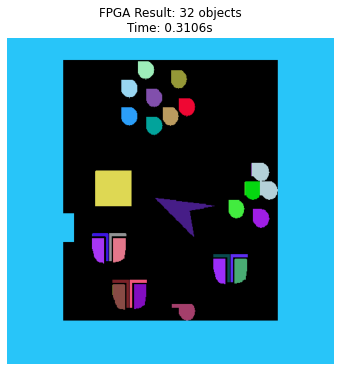

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_matrix
import cv2
import os
import time  

print("--- Step 7: Software Relabeling ---")

start_time = time.time()

os.makedirs("images/fpga", exist_ok=True)

if 'combined_buf' not in locals():
    print("!! Error: 'combined_buf' not found, re-run Step 6.")
else:
    raw_img = np.array(combined_buf, dtype=np.uint32).reshape((512, 512))
    print(f"    Loaded FPGA output. Max Label: {np.max(raw_img)}")

    seams = [128, 256, 384] #borders
    
    max_label_id = np.max(raw_img)
    equivalences = []

    print("    Scanning seams with Neighbor-Search...")
    
    for row in seams:
        row_top = raw_img[row - 1, :]
        row_bot = raw_img[row, :]
        
        # 1. Direct Vertical Overlap
        mask_direct = (row_top > 0) & (row_bot > 0)
        indices_direct = np.where(mask_direct)[0]
        for col in indices_direct:
            equivalences.append((row_top[col], row_bot[col]))

        # 2. Diagonal Left
        mask_diag1 = (row_top[1:] > 0) & (row_bot[:-1] > 0)
        indices_diag1 = np.where(mask_diag1)[0]
        for col in indices_diag1:
             equivalences.append((row_top[col+1], row_bot[col]))

        # 3. Diagonal Right
        mask_diag2 = (row_top[:-1] > 0) & (row_bot[1:] > 0)
        indices_diag2 = np.where(mask_diag2)[0]
        for col in indices_diag2:
             equivalences.append((row_top[col], row_bot[col+1]))

    print(f"    Found {len(equivalences)} equivalences.")

    
    if len(equivalences) > 0:
        row_idx, col_idx = zip(*equivalences)
        data = np.ones(len(equivalences))
        
        graph = csr_matrix((data, (row_idx, col_idx)), shape=(max_label_id + 1, max_label_id + 1))
        n_components, labels_map = connected_components(graph, directed=False)
        
        print(f"    Merging completed. Remapped to {n_components} unique IDs.")
        
        final_img = labels_map[raw_img]
        
        # Force background back to 0
        bg_label = labels_map[0]
        final_img[final_img == bg_label] = 0
        
    else:
        print("   No overlaps")
        final_img = raw_img

        
    unique_objects = np.unique(final_img)
    object_count = len(unique_objects) - 1
    if object_count < 0: object_count = 0
    
    print(f"\n--- Final Result: {object_count} Objects Detected ---")

    # Generate random colors for visualization (ID=0=background=black)
    max_final_id = np.max(final_img)
    colors = np.random.randint(0, 255, size=(max_final_id + 1, 3), dtype=np.uint8)
    colors[0] = [0, 0, 0] 
    # Map labels to colors
    color_img = colors[final_img]

    # Save to disk
    if 'image_name' not in locals(): image_name = 'output'
    
    save_path = f"images/fpga/fpga_{image_name}_labeled.jpg"
    cv2.imwrite(save_path, color_img)
    print(f"    Saved labeled image to: {save_path}")

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"    Total Processing Time: {elapsed_time:.4f} seconds")

    # Display in Notebook
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB))
    plt.title(f"FPGA Result: {object_count} objects\nTime: {elapsed_time:.4f}s")
    plt.axis('off')
    plt.show()

In [4]:
from pynq.overlays.base import BaseOverlay
from pynq.lib.video import VideoMode, PIXEL_BGR
import cv2
import numpy as np
import time

print("--- Step 8: Display FPGA Result on HDMI ---")

# Initialize HDMI
if 'base' not in locals():
    base = BaseOverlay("base.bit")

hdmi_out = base.video.hdmi_out
mode = VideoMode(1280, 720, 24)
hdmi_out.configure(mode, pixelformat=PIXEL_BGR)
hdmi_out.start()


input_path = f"images/fpga/fpga_{image_name}_labeled.jpg"

img = cv2.imread(input_path)

if img is None:
    print(f"Error: Could not load image from {input_path}")
else:
    print(f"    Loaded {input_path}")
    
    out_frame_data = cv2.resize(img, (1280, 720), interpolation=cv2.INTER_NEAREST)
    
    outframe = hdmi_out.newframe()
    outframe[:] = out_frame_data
    hdmi_out.writeframe(outframe)
    
    print("    Image sent to HDMI.")

--- Step 8: Display FPGA Result on HDMI ---
    Loaded images/fpga/fpga_output_labeled.jpg
    Image sent to HDMI.
